In [141]:
!pip install miceforest

In [1]:
import pandas as pd

> **Note:** Данные уже предобработаны с помощью StandartScaler, потому, этот этап обработки был пропущен

In [124]:
df = pd.read_excel("data_raw/side_project/filtered_killip.xlsx")
df = df.drop(columns="Unnamed: 0", errors="ignore")

## Импорт стандартных библиотек для дальнейшей работы

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RepeatedStratifiedKFold,
    GridSearchCV,
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    log_loss,
    accuracy_score,
)
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import shap

In [ ]:
# Настройка стиля графиков
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 13, "axes.labelsize": 12})
sns.set_style("whitegrid")

In [131]:
df[['Класс ОСН по Killip', 'ЧСС (b)', 'ХОБЛ', 'SpO2', 'Диастолического АД(b)']]

,Класс ОСН по Killip,ЧСС (b),ХОБЛ,SpO2,Диастолического АД(b)
0,1,78.0,0.0,99.0,75.0
1,1,74.0,0.0,99.0,75.0
2,3,70.0,0.0,99.0,75.0
3,2,110.0,0.0,99.0,80.0
4,1,72.0,0.0,99.0,100.0
...,...,...,...,...,...
5877,1,75.0,0.0,99.0,80.0
5878,2,65.0,0.0,99.0,100.0
5879,2,69.0,0.0,99.0,80.0
5880,1,69.0,0.0,99.0,80.0


## Подготовка данных

### Импутация пропущенных значений с помощью MICE

Для использования данного подхода лучше всего применять для импутации все колонки, несмотря на то, что они могут быть неиспользованы для дальнейних вычислений и анализа. Такой подход позволит алгоритму лучше выявить нелинейные взаимосвязи и предоставить лучшие результаты. Под капотом используется LightGBM

In [289]:
import pandas as pd
import miceforest as mf
import re

# Функция для очистки имени колонки: оставляет только буквы (латиница/кириллица), цифры и подчеркивания
def clean_column_name(name):
    # Заменяем все символы, кроме букв, цифр и подчеркивания, на '_'
    cleaned = re.sub(r'[^a-zA-Zа-яА-Я0-9_><]', '_', name)
    # Убираем повторяющиеся подчёркивания
    cleaned = re.sub(r'_+', '_', cleaned)
    # Убираем подчёркивания в начале и конце
    cleaned = cleaned.strip('_')
    return cleaned

# Сохраняем оригинальные имена
original_cols = df.columns.tolist()

# Создаём словарь для переименования: старые имена -> новые безопасные
rename_dict = {col: clean_column_name(col) for col in original_cols}
# Проверяем уникальность новых имён (на случай, если два разных имени дадут одинаковое после очистки)
# Если коллизия, можно добавить суффикс
new_names = list(rename_dict.values())
if len(set(new_names)) < len(new_names):
    # Добавляем суффиксы для повторяющихся
    from collections import Counter
    counts = Counter(new_names)
    for col, new_name in rename_dict.items():
        if counts[new_name] > 1:
            # Найдём порядковый номер для этого имени
            idx = [n for n in new_names if n == new_name].index(new_name) + 1
            rename_dict[col] = f"{new_name}_{idx}"

# Переименовываем колонки в датафрейме
df_renamed = df.rename(columns=rename_dict)




# Теперь работаем с переименованным датафреймом
target_cols_orig = ['ЧСС (b)', 'SpO2', 'Диастолического АД(b)', 'Глюкоза в мг/дл', 'SII (тромбоциты*нейтрофилы абс / лимфоциты абс)', 'Apache II']



# Преобразуем оригинальные имена в новые
target_cols = [rename_dict[col] for col in target_cols_orig]

predictor_cols = [col for col in df_renamed.columns if col not in target_cols]
# Исключаем объектные колонки, если они есть
predictor_cols = [
    col for col in predictor_cols 
    if df_renamed[col].dtypes.name not in ['object', 'datetime64', 'timedelta64']
]

variable_schema = {col: predictor_cols for col in target_cols}

kernel = mf.ImputationKernel(
    data=df_renamed,
    variable_schema=variable_schema,
    random_state=42
)

kernel.mice(iterations=5)
df_imputed_renamed = kernel.complete_data(dataset=0)

# Возвращаем исходные имена колонок
# Для этого создаём обратный словарь
reverse_rename = {v: k for k, v in rename_dict.items()}
df_imputed = df_imputed_renamed.rename(columns=reverse_rename)

# df_imputed[['ЧСС (b)', 'SpO2', 'Диастолического АД(b)']]

KeyboardInterrupt: 

In [290]:
df_imputed

,Код пациента,Возраст,Пол,Диагноз Нестабильная стенакордия,Вид STEMI,Инфаркт-зависимая артерия,Поражение ствола,Количество пораженных сосудов(Syntax),Количество пораженных сосудов(Значимость),TIMI,...,ГБ стадия категория,ГБ риск категория,CADILLAC категория,РЕКОРД категория,PAMI категория,TIMI категория,TIMI Летальность категория,APACHE2 выписка категория,APACHE2 1сутки категория,APACHE2 3дня категория
0,15-9993,75.0,0.0,0.0,1.0,ПМЖВ,0,2,2,3.0,...,Средний уровень,Средний уровень,Неизвестно,Высокий риск,Высокий риск,1.0,Высокий риск,Низкий риск (0-10),Критический риск (25+),Критический риск (25+)
1,15-9938,78.0,1.0,0.0,0.0,ОВ,0,2,2,1.0,...,Неизвестно,Неизвестно,Высокий уровень,Умеренный риск,Высокий риск,0.0,Высокий риск,Низкий риск (0-10),Умеренный риск (11-16),Низкий риск (0-10)
2,15-9936,79.0,0.0,0.0,1.0,ПМЖВ,0,1,1,3.0,...,Средний уровень,Средний уровень,Высокий уровень,Высокий риск,Высокий риск,1.0,Очень высокий риск,Низкий риск (0-10),Высокий риск (17-24),Низкий риск (0-10)
3,18-519,76.0,0.0,0.0,1.0,ПМЖВ,0,1,1,1.0,...,Средний уровень,Средний уровень,Высокий уровень,Высокий риск,Высокий риск,0.0,Высокий риск,Низкий риск (0-10),Критический риск (25+),Низкий риск (0-10)
4,15-9774,55.0,0.0,0.0,0.0,ПКА,0,1,1,3.0,...,Средний уровень,Средний уровень,Низкий уровень,Низкий риск,Низкий риск,1.0,Умеренный риск,Низкий риск (0-10),Умеренный риск (11-16),Низкий риск (0-10)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5877,15-10189,52.0,0.0,0.0,1.0,ПМЖВ,0,1,1,3.0,...,Средний уровень,Средний уровень,Низкий уровень,Низкий риск,Средний риск,1.0,Умеренный риск,Низкий риск (0-10),Низкий риск (0-10),Низкий риск (0-10)
5878,21-10,81.0,1.0,0.0,1.0,ПМЖВ,0,2,1,1.0,...,Неизвестно,Неизвестно,Высокий уровень,Умеренный риск,Высокий риск,0.0,Умеренный риск,Низкий риск (0-10),Умеренный риск (11-16),Низкий риск (0-10)
5879,20-1,48.0,0.0,0.0,1.0,ПМЖВ,0,1,1,3.0,...,Неизвестно,Неизвестно,Средний уровень,Умеренный риск,Средний риск,1.0,Высокий риск,Низкий риск (0-10),Низкий риск (0-10),Низкий риск (0-10)
5880,18-6,50.0,0.0,0.0,0.0,ПКА,0,1,1,3.0,...,Неизвестно,Неизвестно,Низкий уровень,Низкий риск,Низкий риск,1.0,Умеренный риск,Низкий риск (0-10),Низкий риск (0-10),Низкий риск (0-10)


### Этап 1

- Класс ОСН по Killip
- ЧСС (b)
- ХОБЛ
- SpO2
- Диастолическое АД(b)

In [291]:
CATEGORICAL = [
    'Класс ОСН по Killip',
    'ХОБЛ',
]

NUMERICAL = [
    'ЧСС (b)',
    'SpO2', 
    'Диастолического АД(b)',
]

TARGET = "КШ развился в реанимации"

df_tmp = df_imputed[
    CATEGORICAL + NUMERICAL + [TARGET]
# ].dropna()
]

X = df_tmp.drop(TARGET, axis=1)
y = df_tmp[TARGET]

for col in CATEGORICAL:
    X[col] = X[col].fillna('missing').astype(str).astype('category')

for col in NUMERICAL:
    X[col].fillna(-1, inplace=True)

X.columns = X.columns.str.replace(' ', '_')
numerical = [x.replace(' ', '_') for x in NUMERICAL]
categorical = [x.replace(' ', '_') for x in CATEGORICAL]


In [170]:
X

,Класс_ОСН_по_Killip,ХОБЛ,ЧСС_(b),SpO2,Диастолического_АД(b)
0,1,0.0,78.0,99.0,75.0
1,1,0.0,74.0,99.0,75.0
2,3,0.0,70.0,99.0,75.0
3,2,0.0,110.0,99.0,80.0
4,1,0.0,72.0,99.0,100.0
...,...,...,...,...,...
5877,1,0.0,75.0,99.0,80.0
5878,2,0.0,65.0,99.0,100.0
5879,2,0.0,69.0,99.0,80.0
5880,1,0.0,69.0,99.0,80.0


### Этап 2

- Класс ОСН по Killip (3)
- ЧСС
- ХОБЛ
- SpO2
- Диастолическое АД
- TIMI

In [264]:
# Эксперимент 2

CATEGORICAL = [
    'Класс ОСН по Killip',
    'ХОБЛ',
    'TIMI'
]

NUMERICAL = [
    'ЧСС (b)',
    'SpO2', 
    'Диастолического АД(b)',
]

TARGET = "КШ развился в реанимации"

df_tmp = df_imputed[
    CATEGORICAL + NUMERICAL + [TARGET]
]

X = df_tmp.drop(TARGET, axis=1)
y = df_tmp[TARGET]

for col in CATEGORICAL:
    X[col] = X[col].fillna('missing').astype(str).astype('category')

for col in NUMERICAL:
    X[col].fillna(-1, inplace=True)

X.columns = X.columns.str.replace(' ', '_')
numerical = [x.replace(' ', '_') for x in NUMERICAL]
categorical = [x.replace(' ', '_') for x in CATEGORICAL]

In [119]:
X

,Класс_ОСН_по_Killip,ЧСС_(b),ХОБЛ,SpO2,Диастолического_АД(b),TIMI_категория
0,-0.471926,0.216658,0.0,0.309224,-0.496152,1.0
1,-0.471926,-0.048257,0.0,0.309224,-0.496152,0.0
2,2.545325,-0.313171,0.0,0.309224,-0.496152,1.0
3,1.036699,2.335973,0.0,0.309224,-0.100455,0.0
4,-0.471926,-0.180714,0.0,0.309224,1.482332,1.0
...,...,...,...,...,...,...
5877,-0.471926,0.017972,0.0,0.309224,-0.100455,1.0
5878,1.036699,-0.644314,0.0,0.309224,1.482332,0.0
5879,1.036699,-0.379400,0.0,0.309224,-0.100455,1.0
5880,-0.471926,-0.379400,0.0,0.309224,-0.100455,1.0


In [ ]:
df_tmp = df[
    [
        "Класс ОСН по Killip",
        "ЧСС (b)",
        "ХОБЛ",
        "SpO2",
        "Диастолического АД(b)",
        "КШ развился в реанимации",
        "TIMI Летальность категория_Высокий риск",
        "TIMI Летальность категория_Неизвестно",
        "TIMI Летальность категория_Низкий риск",
        "TIMI Летальность категория_Очень высокий риск",
        "TIMI Летальность категория_Умеренный риск",
    ]
].dropna()

X = df_tmp.drop("КШ развился в реанимации", axis=1)
y = df_tmp["КШ развился в реанимации"]

### Этап 3

- Класс ОСН по Killip (3)
- ЧСС
- ХОБЛ
- SpO2
- Диастолическое АД
- TIMI
- Глюкоза
- SII 
- Apache II

In [340]:
CATEGORICAL = [
    'Класс ОСН по Killip',
    'ХОБЛ',
    'TIMI'
]

NUMERICAL = [
    'ЧСС (b)',
    'SpO2', 
    'Диастолического АД(b)',
    'Глюкоза в мг/дл', 
    'SII (тромбоциты*нейтрофилы абс / лимфоциты абс)', 
    'Apache II'
]

TARGET = "КШ развился в реанимации"

df_tmp = df_imputed[
    CATEGORICAL + NUMERICAL + [TARGET]
]

X = df_tmp.drop(TARGET, axis=1)
y = df_tmp[TARGET]

for col in CATEGORICAL:
    X[col] = X[col].fillna('missing').astype(str).astype('category')

for col in NUMERICAL:
    X[col].fillna(-1, inplace=True)

X.columns = X.columns.str.replace(' ', '_')
numerical = [x.replace(' ', '_') for x in NUMERICAL]
categorical = [x.replace(' ', '_') for x in CATEGORICAL]

### Этап 4

- Класс ОСН по Killip (3)
- ЧСС
- ХОБЛ
- SpO2
- Диастолическое АД
- TIMI
- Глюкоза
- SII 
- Apache II
- KDIGO 3

In [333]:
CATEGORICAL = [
    'Класс ОСН по Killip',
    'ХОБЛ',
    'TIMI',
    'KDIGO'
]

NUMERICAL = [
    'ЧСС (b)',
    'SpO2', 
    'Диастолического АД(b)',
    'Глюкоза в мг/дл', 
    'SII (тромбоциты*нейтрофилы абс / лимфоциты абс)', 
    'Apache II'
]

TARGET = "КШ развился в реанимации"

df_tmp = df_imputed[
    CATEGORICAL + NUMERICAL + [TARGET]
]

X = df_tmp.drop(TARGET, axis=1)
y = df_tmp[TARGET]

for col in CATEGORICAL:
    X[col] = X[col].fillna('missing').astype(str).astype('category')

for col in NUMERICAL:
    X[col].fillna(-1, inplace=True)

X.columns = X.columns.str.replace(' ', '_')
numerical = [x.replace(' ', '_') for x in NUMERICAL]
categorical = [x.replace(' ', '_') for x in CATEGORICAL]

In [341]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
X_train, X_calib, y_train, y_calib = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

print(f"Train:      {X_train.shape[0]} | класс 1: {y_train.mean():.2%}")
print(f"Calibration:{X_calib.shape[0]} | класс 1: {y_calib.mean():.2%}")
print(f"Test:       {X_test.shape[0]} | класс 1: {y_test.mean():.2%}")


Train:      3528 | класс 1: 3.40%
Calibration:1177 | класс 1: 3.40%
Test:       1177 | класс 1: 3.40%


## Подготовка основных инструментов и функций

In [172]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Полная оценка модели на тестовой выборке.
    Возвращает словарь метрик.
    """
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    metrics = {
        "Model": model_name,
        "ROC-AUC": roc_auc_score(y_test, y_pred_proba),
        "PR-AUC": average_precision_score(y_test, y_pred_proba),
        "Brier Score": brier_score_loss(y_test, y_pred_proba),
        "Log Loss": log_loss(y_test, y_pred_proba),
        "Accuracy": accuracy_score(y_test, y_pred),
    }
    return metrics, y_pred_proba


def net_benefit(y_true, y_prob, threshold):
    """Net benefit для DCA"""
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    n = len(y_true)
    return tp / n - fp / n * (threshold / (1 - threshold))


def decision_curve_data(y_true, y_prob, thresholds=None):
    """Возвращает данные для DCA-графика"""
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 100)
    nb_model = [net_benefit(y_true, y_prob, t) for t in thresholds]
    nb_all = [net_benefit(y_true, np.ones_like(y_true), t) for t in thresholds]
    return thresholds, nb_model, nb_all


def plot_calibration_curve(y_true, y_pred_proba_list, labels, colors, n_bins=10):
    """Калибровочные кривые для нескольких моделей"""
    plt.figure(figsize=(7, 7))
    for y_pred_proba, label, color in zip(y_pred_proba_list, labels, colors):
        prob_true, prob_pred = calibration_curve(y_true, y_pred_proba, n_bins=n_bins, strategy="uniform")
        plt.plot(prob_pred, prob_true, "s-", color=color, linewidth=2, markersize=6, label=label)
    plt.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Идеальная калибровка")
    plt.xlabel("Предсказанная вероятность", fontsize=13)
    plt.ylabel("Наблюдаемая частота", fontsize=13)
    plt.title("📐 Calibration Plots", fontsize=15)
    plt.legend(fontsize=10, loc="lower right")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

In [293]:
inner_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

scoring_metrics = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "brier": "neg_brier_score",  # негативный — чем выше, тем лучше
    "log_loss": "neg_log_loss",
}

from sklearn.metrics import make_scorer

scoring_metrics["brier"] = make_scorer(brier_score_loss, greater_is_better=False, needs_proba=True)

cv_results_all = {}

## Обучение baseline моделей

### Логистическая регрессия

In [301]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical),
    ('cat', categorical_transformer, categorical)
])

params = {'penalty': 'l2', 'solver': 'sag', 'C': 0.031051713805601528, 'l1_ratio': 0.7127045374733961, 'max_iter': 800, 'tol': 0.05904402276163892, 'class_weight': None, 'fit_intercept': True}

# Pipeline: препроцессинг → модель
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(**params))
])

# lr_baseline = LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=2000, random_state=42)

# Кросс-валидация
# lr_cv = cross_validate(
#     lr_pipeline, X_train, y_train, cv=inner_cv, scoring=scoring_metrics, n_jobs=-1, return_train_score=True
# )

# print("📊 Logistic Regression — CV Results (mean ± std):")
# for key in scoring_metrics:
#     val = lr_cv[f"test_{key}"]
#     if key == "brier":
#         val = -val  # возвращаем к нормальному Brier
#     print(f"  {key:12s}: {val.mean():.4f} ± {val.std():.4f}")

#-------------------------------

# Обучаем финальную модель на всех train
lr_pipeline.fit(X_train, y_train)

# Оценка на тесте
# lr_metrics, lr_proba = evaluate_model(lr_pipeline, X_test, y_test, "Logistic Regression")
# cv_results_all["Logistic Regression"] = lr_cv

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### Случайный лес

In [309]:
categorical_transformer_rf = Pipeline([
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor_rf = ColumnTransformer([
    ('cat', categorical_transformer_rf, categorical)
])

params = {'n_estimators': 340, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 119, 'max_features': None, 'bootstrap': True, 'class_weight': 'balanced_subsample', 'criterion': 'entropy', 'min_impurity_decrease': 0.005255287738165042, 'max_leaf_nodes': 85}

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(
        # n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1
        **params
    ))
])

rf_pipeline.fit(X_train, y_train)

# rf_baseline = RandomForestClassifier(
#     n_estimators=300, max_depth=10, min_samples_leaf=20, class_weight="balanced", random_state=42, n_jobs=-1
# )

# Кросс-валидация
# rf_cv = cross_validate(
#     rf_pipeline, X_train, y_train, cv=inner_cv, scoring=scoring_metrics, n_jobs=-1, return_train_score=True
# )

# print("📊 Random Forest — CV Results (mean ± std):")
# for key in scoring_metrics:
#     val = rf_cv[f"test_{key}"]
#     if key == "brier":
#         val = -val
#     print(f"  {key:12s}: {val.mean():.4f} ± {val.std():.4f}")

# Обучаем финальную модель + калибровка изотонической регрессией
# rf_pipeline.fit(X_train, y_train)
# rf_calibrated = CalibratedClassifierCV(
#     estimator=rf_pipeline,
#     method="isotonic",  # изотоническая регрессия лучше для RF
#     cv=5,
#     n_jobs=-1,
# )
# rf_calibrated.fit(X_calib, y_calib)

# # Оценка на тесте
# rf_metrics, rf_proba = evaluate_model(rf_calibrated, X_test, y_test, "Random Forest")
# cv_results_all["Random Forest"] = rf_cv

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

### XGBoost

In [312]:
params = {'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.004027330747598759, 'subsample': 0.7697002196913415, 'colsample_bytree': 0.6671745707189732, 'colsample_bylevel': 0.7275129315434953, 'colsample_bynode': 0.9769357373727756, 'gamma': 1.858178137207479, 'booster': 'dart', 'min_child_weight': 17, 'reg_alpha': 1.7338444939539736e-07, 'reg_lambda': 1.7564634054848673e-08, 'scale_pos_weight': 12.675771709705893}

xgb_baseline = XGBClassifier(
    **params,

    # n_estimators=300,
    # max_depth=6,
    # learning_rate=0.05,
    # subsample=0.8,
    # colsample_bytree=0.8,
    # scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # баланс классов
    # eval_metric="logloss",
    # random_state=42,
    # verbosity=0,

    enable_categorical=True,
    # tree_method='hist'
)

# Кросс-валидация
# xgb_cv = cross_validate(
#     xgb_baseline, X_train, y_train, cv=inner_cv, scoring=scoring_metrics, n_jobs=-1, return_train_score=True
# )

# print("📊 XGBoost — CV Results (mean ± std):")
# for key in scoring_metrics:
#     val = xgb_cv[f"test_{key}"]
#     if key == "brier":
#         val = -val
#     print(f"  {key:12s}: {val.mean():.4f} ± {val.std():.4f}")

xgb_baseline.fit(X_train, y_train)
# xgb_metrics, xgb_proba = evaluate_model(xgb_baseline, X_test, y_test, "XGBoost")
# cv_results_all["XGBoost"] = xgb_cv

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,'dart'
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,0.7275129315434953
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,0.9769357373727756
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6671745707189732
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python 

### LightGBM

In [231]:
tmp_categorical = [f"name:{x}" for x in categorical]

lgb_baseline = LGBMClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    verbose=-1,

    categorical_feature=tmp_categorical,
)

lgb_cv = cross_validate(
    lgb_baseline, X_train, y_train, cv=inner_cv, scoring=scoring_metrics, n_jobs=-1, return_train_score=True
)

print("📊 LightGBM — CV Results (mean ± std):")
for key in scoring_metrics:
    val = lgb_cv[f"test_{key}"]
    if key == "brier":
        val = -val
    print(f"  {key:12s}: {val.mean():.4f} ± {val.std():.4f}")

lgb_baseline.fit(X_train, y_train)
lgb_metrics, lgb_proba = evaluate_model(lgb_baseline, X_test, y_test, "LightGBM")
cv_results_all["LightGBM"] = lgb_cv

📊 LightGBM — CV Results (mean ± std):
  roc_auc     : 0.7524 ± 0.0533
  pr_auc      : 0.1455 ± 0.0389
  brier       : nan ± nan
  log_loss    : -0.1675 ± 0.0184


### CatBoost

#### Работает

In [319]:
import sklearn
print(f"sklearn version: {sklearn.__version__}")

CATEGORICAL_INDEXES = X.columns.get_indexer(categorical).tolist()
print(CATEGORICAL_INDEXES)

params = {'iterations': 700, 'depth': 4, 'learning_rate': 0.0047619637019393445, 'l2_leaf_reg': 18.107309376215408, 'border_count': 64, 'bagging_temperature': 0.0952715148651731, 'rsm': 0.8214914285438565, 'one_hot_max_size': 3, 'grow_policy': 'Depthwise', 'min_data_in_leaf': 45, 'leaf_estimation_method': 'Newton'}

# cat_features НЕ в конструкторе!
cbt_baseline = CatBoostClassifier(
    # iterations=500, depth=6, learning_rate=0.05,
    # l2_leaf_reg=3, border_count=128,
    # auto_class_weights='Balanced',
    # random_seed=42, verbose=0,

    **params
)

# Передаём cat_features как fit-параметр (sklearn ≥ 1.3)
# cbt_cv = cross_validate(
#     cbt_baseline, X_train, y_train,
#     cv=inner_cv, scoring=scoring_metrics, n_jobs=-1,
#     params={'cat_features': CATEGORICAL_INDEXES},   # 🔑
# )

# print("📊 CatBoost — CV Results (mean ± std):")
# for key in scoring_metrics:
#     val = cbt_cv[f'test_{key}']
#     if key == 'brier':
#         val = -val
#     print(f"  {key:12s}: {val.mean():.4f} ± {val.std():.4f}")

cbt_baseline.fit(X_train, y_train, cat_features=CATEGORICAL_INDEXES)
# cbt_metrics, cbt_proba = evaluate_model(cbt_baseline, X_test, y_test, "CatBoost")

sklearn version: 1.8.0
[0, 1, 2]
0:	learn: 0.6857523	total: 9.5ms	remaining: 6.64s
1:	learn: 0.6778085	total: 12.9ms	remaining: 4.51s
2:	learn: 0.6698042	total: 15.8ms	remaining: 3.67s
3:	learn: 0.6624664	total: 18.9ms	remaining: 3.3s
4:	learn: 0.6546856	total: 21.3ms	remaining: 2.96s
5:	learn: 0.6477165	total: 23.9ms	remaining: 2.77s
6:	learn: 0.6403918	total: 26.5ms	remaining: 2.62s
7:	learn: 0.6333581	total: 28.8ms	remaining: 2.49s
8:	learn: 0.6259812	total: 31.2ms	remaining: 2.39s
9:	learn: 0.6192820	total: 33.5ms	remaining: 2.31s
10:	learn: 0.6122152	total: 35.8ms	remaining: 2.24s
11:	learn: 0.6052089	total: 38ms	remaining: 2.18s
12:	learn: 0.5987278	total: 40.1ms	remaining: 2.12s
13:	learn: 0.5923249	total: 43.2ms	remaining: 2.12s
14:	learn: 0.5861191	total: 44.9ms	remaining: 2.05s
15:	learn: 0.5800108	total: 47.4ms	remaining: 2.02s
16:	learn: 0.5741269	total: 49ms	remaining: 1.97s
17:	learn: 0.5676888	total: 51.3ms	remaining: 1.94s
18:	learn: 0.5617970	total: 53.9ms	remaining: 1

CatBoostClassifier(bagging_temperature=0.0952715148651731, border_count=64, depth=4, grow_policy='Depthwise', iterations=700, l2_leaf_reg=18.107309376215408, leaf_estimation_method='Newton', learning_rate=0.0047619637019393445, min_data_in_leaf=45, one_hot_max_size=3, rsm=0.8214914285438565)

In [232]:
all_metrics = [lr_metrics, rf_metrics, xgb_metrics, lgb_metrics, cbt_metrics]
df_results = pd.DataFrame(all_metrics).set_index("Model")
df_results = df_results.round(4)


# Раскрашиваем таблицу
def highlight_best(s):
    if s.name in ["Brier Score", "Log Loss"]:
        # Для ошибок — минимум лучший
        is_best = s == s.min()
    else:
        is_best = s == s.max()
    return ["background-color: #c8e6c9; font-weight: bold" if v else "" for v in is_best]


print("=" * 70)
print("📊 СВОДНАЯ ТАБЛИЦА МЕТРИК (Test set)")
print("=" * 70)
display(
    df_results.style.apply(highlight_best, axis=0)
    .format("{:.4f}")
    .set_caption("Лучшее значение в каждом столбце выделено зелёным")
)

📊 СВОДНАЯ ТАБЛИЦА МЕТРИК (Test set)


,ROC-AUC,PR-AUC,Brier Score,Log Loss,Accuracy
Model,,,,,
Logistic Regression,0.7894,0.2217,0.0297,0.1230,0.9652
Random Forest,0.6550,0.0568,0.0323,0.1404,0.9660
XGBoost,0.8342,0.2804,0.0337,0.1300,0.9584
LightGBM,0.8167,0.2909,0.0333,0.1365,0.9601
CatBoost,0.8235,0.3087,0.0451,0.1660,0.9431


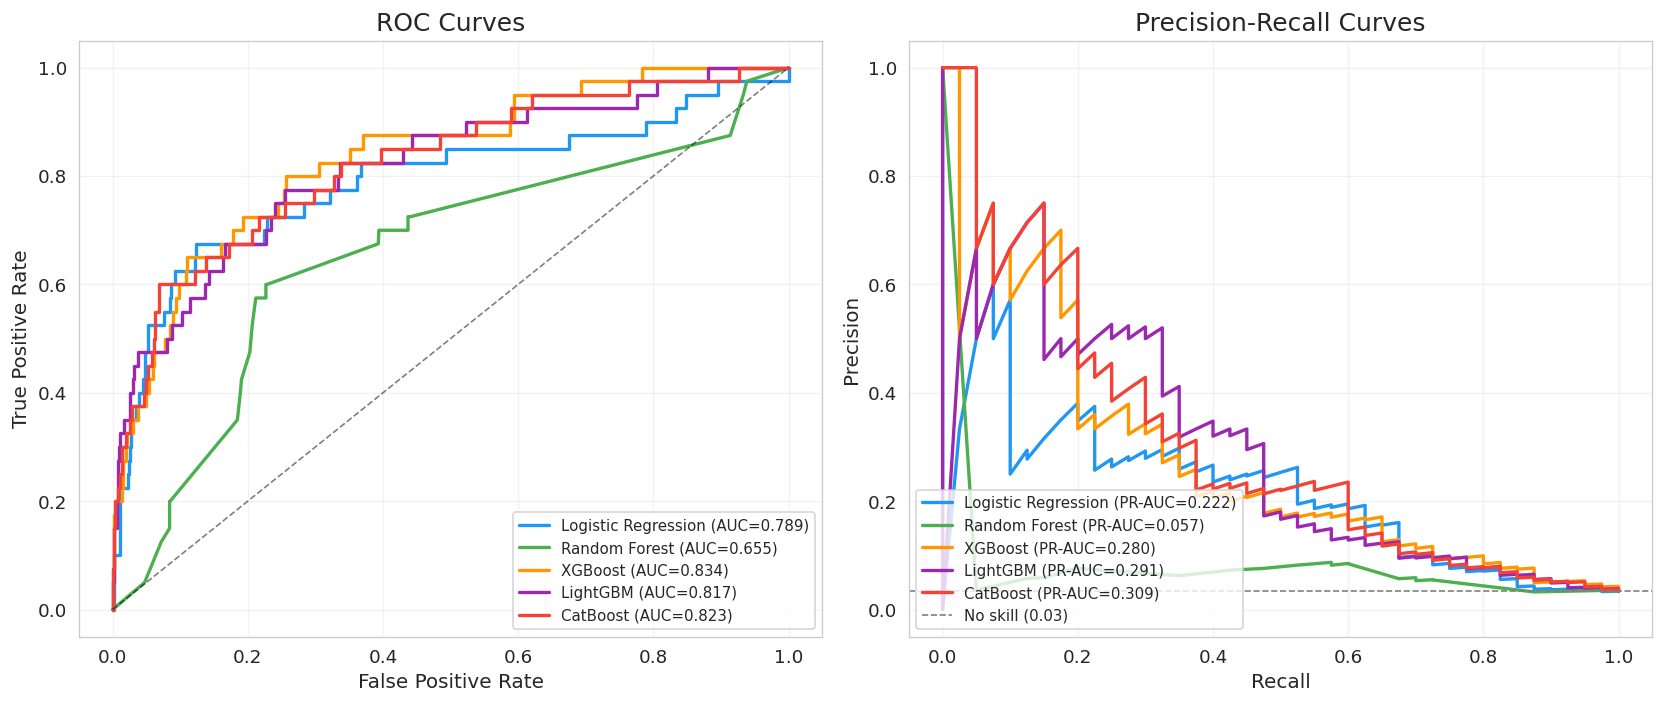

In [233]:
models_data = [
    (lr_proba, "Logistic Regression", "#2196F3"),
    (rf_proba, "Random Forest", "#4CAF50"),
    (xgb_proba, "XGBoost", "#FF9800"),
    (lgb_proba, "LightGBM", "#9C27B0"),
    (cbt_proba, "CatBoost", "#F44336"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- ROC-кривые ---
ax = axes[0]
for proba, label, color in models_data:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{label} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves", fontsize=15)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.25)

# --- PR-кривые ---
ax = axes[1]
for proba, label, color in models_data:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    ax.plot(recall, precision, color=color, linewidth=2, label=f"{label} (PR-AUC={pr_auc:.3f})")
no_skill = y_test.mean()
ax.axhline(y=no_skill, color="gray", linestyle="--", linewidth=1, label=f"No skill ({no_skill:.2f})")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curves", fontsize=15)
ax.legend(fontsize=9, loc="lower left")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

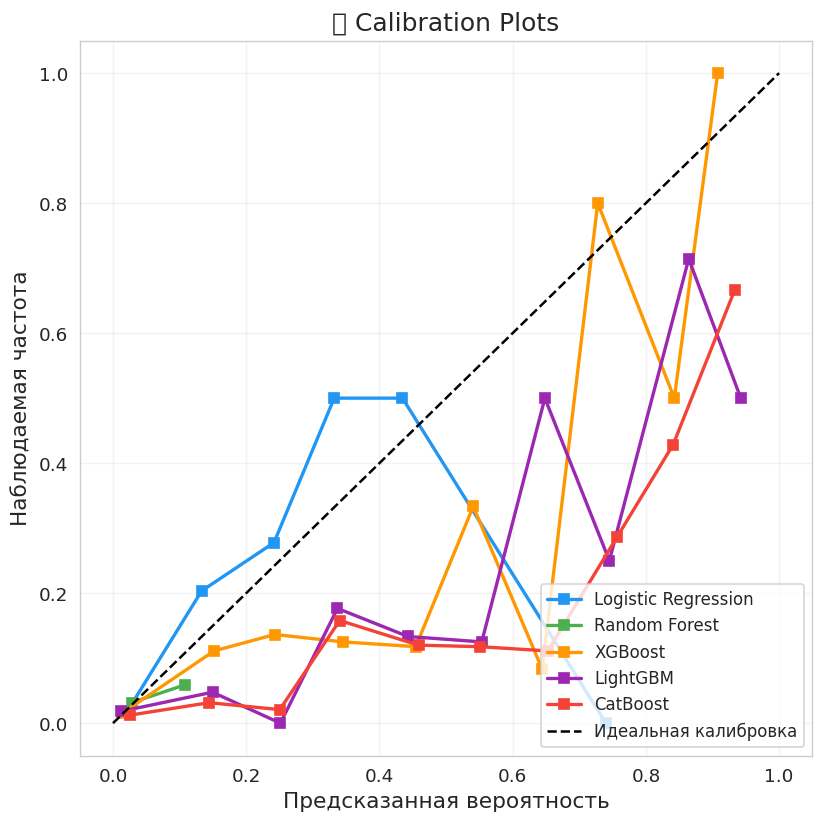

In [234]:
plot_calibration_curve(
    y_test,
    [lr_proba, rf_proba, xgb_proba, lgb_proba, cbt_proba],
    ["Logistic Regression", "Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336"],
    n_bins=10,
)

## Optuna Hyperparams tune

In [236]:
import optuna

In [260]:
def optuna_tune_model(model_name, X_train, y_train, n_trials=50, cv_folds=3, 
                      random_state=42, cat_features=None):
    """
    Подбор гиперпараметров одной модели через Optuna.
    
    Параметры
    ---------
    model_name : str
        'LogisticRegression', 'RandomForest', 'XGBoost', 'LightGBM', 'CatBoost'
    X_train, y_train : np.array
        Обучающие данные.
    n_trials : int
        Количество испытаний Optuna.
    cv_folds : int
        Количество фолдов для внутренней кросс-валидации.
    random_state : int
    cat_features : list или None
        Индексы категориальных признаков (только для CatBoost).
    
    Возвращает
    ----------
    dict: {'best_params': dict, 'best_score': float, 'study': optuna.Study}
    """
    
    scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    
    # ── Logistic Regression ──
    if model_name == 'LogisticRegression':
        def objective(trial):
            penalty =  trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])

            if penalty == 'l1':
                solver = 'saga'          # l1 → только saga (или liblinear для маленьких данных)
            elif penalty == 'elasticnet':
                solver = 'saga'           # elasticnet → только saga
                l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
            else:  # l2
                solver = trial.suggest_categorical('solver_l2', ['lbfgs', 'newton-cg', 'sag', 'saga'])


            params = {
                'C': trial.suggest_float('C', 1e-4, 1e4, log=True),
                'penalty': penalty,
                'l1_ratio': trial.suggest_float('l1_ratio', 0, 1),
                'solver': solver,
                'max_iter': trial.suggest_int('max_iter', 100, 1000, step=100),
                'tol': trial.suggest_float('tol', 1e-5, 1e-1, log=True),
                'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
                'fit_intercept': trial.suggest_categorical('fit_intercept', [True, False]),  
                'random_state': random_state,
            }

            if penalty == 'elasticnet':
                params['l1_ratio'] = l1_ratio

            numeric_transformer = Pipeline([
                ('scaler', StandardScaler())
            ])

            categorical_transformer = Pipeline([
                ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
            ])

            preprocessor = ColumnTransformer([
                ('num', numeric_transformer, numerical),
                ('cat', categorical_transformer, categorical)
            ])

            # Pipeline: препроцессинг → модель
            lr_pipeline = Pipeline([
                ('preprocessor', preprocessor),
                ('classifier', LogisticRegression(**params))
            ])

            # model = LogisticRegression(**params)
            scores = cross_validate(lr_pipeline, X_train, y_train, cv=cv, 
                                    scoring='roc_auc', n_jobs=-1)
            return scores['test_score'].mean()
    
    # ── Random Forest ──
    elif model_name == 'RandomForest':
        def objective(trial):
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=10),
                'max_depth': trial.suggest_int('max_depth', 3, 20),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),

                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 200),
                'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
                'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
                'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None]),
                'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
                'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.01, log=False),
                'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 10, 100), 
                'random_state': random_state,
                'n_jobs': -1,
            }

            categorical_transformer_rf = Pipeline([
                ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
            ])

            preprocessor_rf = ColumnTransformer([
                ('cat', categorical_transformer_rf, categorical)
            ])

            rf_pipeline = Pipeline([
                ('preprocessor', preprocessor_rf),
                ('classifier', RandomForestClassifier(**params))
            ])

            # model = RandomForestClassifier(**params)
            scores = cross_validate(rf_pipeline, X_train, y_train, cv=cv,
                                    scoring='roc_auc', n_jobs=-1)
            return scores['test_score'].mean()
    
    # ── XGBoost ──
    elif model_name == 'XGBoost':
        def objective(trial):
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 600, step=50),
                'max_depth': trial.suggest_int('max_depth', 2, 12),
                'learning_rate': trial.suggest_float('learning_rate', 1e-3, 1, log=True),
                'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
                'colsample_bynode': trial.suggest_float('colsample_bynode', 0.5, 1.0), 
                'gamma': trial.suggest_float('gamma', 0, 5), 
                'booster': trial.suggest_categorical('booster', ['gbtree', 'dart']),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
                'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
                'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, scale_pos_weight * 2),
                'eval_metric': 'logloss',
                'random_state': random_state,
                'verbosity': 0,
                'enable_categorical': True,
                'n_jobs': -1,
            }
            model = XGBClassifier(**params)
            scores = cross_validate(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
            return scores['test_score'].mean()
    

    # ── LightGBM ──
    elif model_name == 'LightGBM':
        def objective(trial):
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 600, step=50),
                'max_depth': trial.suggest_int('max_depth', 3, 15),
                'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
                'num_leaves': trial.suggest_int('num_leaves', 8, 128, step=8),
                'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
                'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),

                'min_split_gain': trial.suggest_float('min_split_gain', 0, 1),
                'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt', 'dart', 'goss', 'rf']),
                'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 10),

                'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
                'random_state': random_state,
                'verbose': -1,
            }
            model = LGBMClassifier(**params)
            scores = cross_validate(model, X_train, y_train, cv=cv,
                                    scoring='roc_auc', n_jobs=-1)
            return scores['test_score'].mean()


    # ── CatBoost ──
    elif model_name == 'CatBoost':
        cb_cat_features = cat_features if cat_features is not None else []

        CATEGORICAL_INDEXES = X_train.columns.get_indexer(categorical).tolist()
        print(CATEGORICAL_INDEXES)

        def objective(trial):
            params = {
                'iterations': trial.suggest_int('iterations', 100, 1000, step=50),
                'depth': trial.suggest_int('depth', 3, 12),
                'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
                'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 20.0, log=True),
                'border_count': trial.suggest_categorical('border_count', [64, 128, 254]),


                'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
                'rsm': trial.suggest_float('rsm', 0.5, 1.0),
                'one_hot_max_size': trial.suggest_int('one_hot_max_size', 2, 20),
                'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),
                'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50),
                'leaf_estimation_method': trial.suggest_categorical('leaf_estimation_method', ['Newton', 'Gradient']),
                'loss_function': 'Logloss',

                'auto_class_weights': 'Balanced',
                'random_seed': random_state,
                'verbose': 0,
            }
            model = CatBoostClassifier(**params)
            scores = cross_validate(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1, params={'cat_features': CATEGORICAL_INDEXES})
            return scores['test_score'].mean()
    
    else:
        raise ValueError(f"Неизвестная модель: {model_name}")
    
    # Запуск Optuna
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=random_state),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    return {
        'best_params': study.best_params,
        'best_score': study.best_value,
        'study': study,
    }

In [261]:
def optuna_tune_all_models(X_train, y_train, model_names=None, n_trials=50, cv_folds=5, random_state=42, cat_features=None):
    """
    Тюнинг всех моделей. Возвращает словарь {model_name: result}.
    
    result = {'best_params': dict, 'best_score': float, 'study': optuna.Study}
    """
    if model_names is None:
        model_names = ['LogisticRegression', 'RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']
    
    results = {}
    for name in model_names:
        print(f"\n🔧 {name} ...")
        results[name] = optuna_tune_model(
            model_name=name,
            X_train=X_train, y_train=y_train,
            n_trials=n_trials, cv_folds=cv_folds,
            random_state=random_state, cat_features=cat_features,
        )
        print(f"   Best AUC = {results[name]['best_score']:.4f}")
        print(f"   Best params = {results[name]['best_params']}")
    
    return results

### Запуск подбора гиперпараметров для всех моделей каждого из этапов

In [287]:
results = optuna_tune_all_models(X_train, y_train, n_trials=50, cat_features=categorical, model_names=['LogisticRegression', 'RandomForest', 'XGBoost', 'CatBoost'])
best_params_lr = results['LogisticRegression']['best_params']

[I 2026-07-23 05:07:20,503] A new study created in memory with name: no-name-a2a508ce-0e51-40be-bd64-3cc355fe1a76



🔧 LogisticRegression ...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-23 05:07:20,633] Trial 0 finished with value: 0.8106244697938602 and parameters: {'penalty': 'l2', 'solver_l2': 'lbfgs', 'C': 849.9808989183019, 'l1_ratio': 0.6011150117432088, 'max_iter': 800, 'tol': 1.2087541473056957e-05, 'class_weight': None, 'fit_intercept': True}. Best is trial 0 with value: 0.8106244697938602.
[I 2026-07-23 05:07:20,719] Trial 1 finished with value: 0.8168441197537403 and parameters: {'penalty': 'elasticnet', 'l1_ratio': 0.43194501864211576, 'C': 0.02137140731637301, 'max_iter': 700, 'tol': 3.613894271216525e-05, 'class_weight': 'balanced', 'fit_intercept': False}. Best is trial 1 with value: 0.8168441197537403.
[I 2026-07-23 05:07:20,968] Trial 2 finished with value: 0.8063668516915639 and parameters: {'penalty': 'elasticnet', 'l1_ratio': 0.046450412719997725, 'C': 7.250347382396653, 'max_iter': 200, 'tol': 1.8205657658407255e-05, 'class_weight': 'balanced', 'fit_intercept': True}. Best is trial 1 with value: 0.8168441197537403.
[I 2026-07-23 05:07:2

[I 2026-07-23 05:07:26,600] A new study created in memory with name: no-name-1b8ac8a9-8943-418a-8f5d-1eb5958fb4fc


[I 2026-07-23 05:07:26,533] Trial 48 finished with value: 0.8143471807746356 and parameters: {'penalty': 'l2', 'solver_l2': 'sag', 'C': 35.36052437110351, 'l1_ratio': 0.34123071665164517, 'max_iter': 900, 'tol': 0.032003208047999526, 'class_weight': None, 'fit_intercept': True}. Best is trial 32 with value: 0.8201777078731036.
[I 2026-07-23 05:07:26,593] Trial 49 finished with value: 0.8112042694961554 and parameters: {'penalty': 'l2', 'solver_l2': 'lbfgs', 'C': 0.10078813779360352, 'l1_ratio': 0.5022027775304236, 'max_iter': 800, 'tol': 0.01029989702152599, 'class_weight': None, 'fit_intercept': True}. Best is trial 32 with value: 0.8201777078731036.
   Best AUC = 0.8202
   Best params = {'penalty': 'l2', 'solver_l2': 'sag', 'C': 0.031051713805601528, 'l1_ratio': 0.7127045374733961, 'max_iter': 800, 'tol': 0.05904402276163892, 'class_weight': None, 'fit_intercept': True}

🔧 RandomForest ...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-23 05:07:27,477] Trial 0 finished with value: 0.7286489037741346 and parameters: {'n_estimators': 220, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 120, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None, 'criterion': 'gini', 'min_impurity_decrease': 0.0018182496720710061, 'max_leaf_nodes': 26}. Best is trial 0 with value: 0.7286489037741346.
[I 2026-07-23 05:07:27,990] Trial 1 finished with value: 0.7383934556593361 and parameters: {'n_estimators': 180, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 59, 'max_features': 'sqrt', 'bootstrap': False, 'class_weight': 'balanced', 'criterion': 'gini', 'min_impurity_decrease': 0.006075448519014384, 'max_leaf_nodes': 25}. Best is trial 1 with value: 0.7383934556593361.
[I 2026-07-23 05:07:28,261] Trial 2 finished with value: 0.7358207985783658 and parameters: {'n_estimators': 70, 'max_depth': 20, 'min_samples_split': 20, 'min_samples_leaf': 162, 'max_features': None, 'bootstrap': True, 'c

[I 2026-07-23 05:08:34,193] A new study created in memory with name: no-name-7816efff-0f8a-490d-baac-1ca119f4b52c


[I 2026-07-23 05:08:34,190] Trial 49 finished with value: 0.7444116452287549 and parameters: {'n_estimators': 300, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 81, 'max_features': None, 'bootstrap': False, 'class_weight': 'balanced_subsample', 'criterion': 'gini', 'min_impurity_decrease': 0.00313229730525918, 'max_leaf_nodes': 95}. Best is trial 24 with value: 0.763552149676386.
   Best AUC = 0.7636
   Best params = {'n_estimators': 340, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 119, 'max_features': None, 'bootstrap': True, 'class_weight': 'balanced_subsample', 'criterion': 'entropy', 'min_impurity_decrease': 0.005255287738165042, 'max_leaf_nodes': 85}

🔧 XGBoost ...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-23 05:08:47,046] Trial 0 finished with value: 0.7963385273798091 and parameters: {'n_estimators': 250, 'max_depth': 12, 'learning_rate': 0.15702970884055384, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'colsample_bylevel': 0.5779972601681014, 'colsample_bynode': 0.5290418060840998, 'gamma': 4.330880728874676, 'booster': 'dart', 'min_child_weight': 1, 'reg_alpha': 5.360294728728285, 'reg_lambda': 0.31044435499483225, 'scale_pos_weight': 12.848522375847809}. Best is trial 0 with value: 0.7963385273798091.
[I 2026-07-23 05:08:52,189] Trial 1 finished with value: 0.815523951322232 and parameters: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.008179499475211672, 'subsample': 0.762378215816119, 'colsample_bytree': 0.7159725093210578, 'colsample_bylevel': 0.645614570099021, 'colsample_bynode': 0.8059264473611898, 'gamma': 0.6974693032602092, 'booster': 'dart', 'min_child_weight': 10, 'reg_alpha': 0.1165691561324743, 'reg_lambda': 6.2670626960

[I 2026-07-23 05:15:44,818] A new study created in memory with name: no-name-553a7b48-0c19-413b-bb38-8b76aa36b63b


[I 2026-07-23 05:15:44,810] Trial 49 finished with value: 0.8025334882145312 and parameters: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.07798564430101863, 'subsample': 0.5213821517568378, 'colsample_bytree': 0.7053693408122312, 'colsample_bylevel': 0.8200857374989182, 'colsample_bynode': 0.9325469676976273, 'gamma': 4.132667259895306, 'booster': 'dart', 'min_child_weight': 20, 'reg_alpha': 3.9396695830542915e-06, 'reg_lambda': 1.6760728929351234e-06, 'scale_pos_weight': 21.229488998584948}. Best is trial 41 with value: 0.830149566576666.
   Best AUC = 0.8301
   Best params = {'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.004027330747598759, 'subsample': 0.7697002196913415, 'colsample_bytree': 0.6671745707189732, 'colsample_bylevel': 0.7275129315434953, 'colsample_bynode': 0.9769357373727756, 'gamma': 1.858178137207479, 'booster': 'dart', 'min_child_weight': 17, 'reg_alpha': 1.7338444939539736e-07, 'reg_lambda': 1.7564634054848673e-08, 'scale_pos_weight': 12.6757

  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-23 05:15:49,025] Trial 0 finished with value: 0.6326322590693062 and parameters: {'iterations': 450, 'depth': 12, 'learning_rate': 0.06504856968981275, 'l2_leaf_reg': 0.0036994785934391697, 'border_count': 64, 'bagging_temperature': 0.8661761457749352, 'rsm': 0.8005575058716043, 'one_hot_max_size': 15, 'grow_policy': 'Depthwise', 'min_data_in_leaf': 11, 'leaf_estimation_method': 'Gradient'}. Best is trial 0 with value: 0.6326322590693062.
[I 2026-07-23 05:15:50,128] Trial 1 finished with value: 0.6670931102986666 and parameters: {'iterations': 350, 'depth': 8, 'learning_rate': 0.01174843954800703, 'l2_leaf_reg': 5.113649633234538e-06, 'border_count': 64, 'bagging_temperature': 0.3663618432936917, 'rsm': 0.728034992108518, 'one_hot_max_size': 16, 'grow_policy': 'Lossguide', 'min_data_in_leaf': 3, 'leaf_estimation_method': 'Newton'}. Best is trial 1 with value: 0.6670931102986666.
[I 2026-07-23 05:15:50,841] Trial 2 finished with value: 0.7160338463503876 and parameters: {'ite

In [269]:
print(results.keys())

dict_keys(['LogisticRegression', 'RandomForest', 'XGBoost', 'CatBoost'])


In [271]:
print(results['LogisticRegression'].keys())

dict_keys(['best_params', 'best_score', 'study'])


In [279]:
results['CatBoost']['best_params']

{'iterations': 800,
 'depth': 3,
 'learning_rate': 0.0026569633951470935,
 'l2_leaf_reg': 1.0533527781779843,
 'border_count': 64,
 'bagging_temperature': 0.5717729654107032,
 'rsm': 0.9354675756541166,
 'one_hot_max_size': 20,
 'grow_policy': 'Lossguide',
 'min_data_in_leaf': 44,
 'leaf_estimation_method': 'Gradient'}

## SHAP интерпретация

In [354]:
# ═══════════════════════════════════════════════════════════
# БЛОК 4 (v5): SHAP — правильный фикс CatBoost
# ═══════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import os
from sklearn.pipeline import Pipeline


def _ensure_numeric(X):
    """
    Преобразует X в numeric, СОХРАНЯЯ имена колонок DataFrame.
    """
    if isinstance(X, pd.DataFrame):
        X = X.copy()
        for col in X.columns:
            if X[col].dtype == object or str(X[col].dtype) == 'category':
                X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0).astype(float)
            else:
                X[col] = X[col].astype(float)
        return X                                           # ← DataFrame, не numpy!
    elif isinstance(X, np.ndarray):
        if X.dtype.kind in ('U', 'S', 'O'):
            try:
                return X.astype(np.float64)
            except (ValueError, TypeError):
                return pd.DataFrame(X).apply(
                    pd.to_numeric, errors='coerce').fillna(0).values
        return X.astype(np.float64)
    return np.array(X, dtype=np.float64)


def _is_catboost(model):
    """Проверяет, является ли модель CatBoost."""
    name = type(model).__name__
    return 'CatBoost' in name or 'catboost' in str(type(model)).lower()


def _catboost_shap(model, X, feature_names, cat_features=None):
    """
    SHAP для CatBoost.
    Категориальные колонки → int (через создание нового DataFrame).
    """
    import catboost as cb
    
    if cat_features is None:
        cat_features = []
    
    cat_set = set(int(c) for c in cat_features)
    n_features = X.shape[1]
    
    # 🔑 Создаём словарь колонок С НУЖНЫМИ dtype
    data = {}
    for i in range(n_features):
        col_name = feature_names[i] if isinstance(feature_names, (list, np.ndarray)) else str(i)
        
        if isinstance(X, pd.DataFrame):
            vals = X.iloc[:, i].fillna(0).values
        else:
            vals = X[:, i]
        
        if i in cat_set:
            # Берём целую часть, конвертируем в int, потом в str 
            # (CatBoost гарантированно принимает строки)
            data[col_name] = vals.astype(np.int64)
        else:
            data[col_name] = vals.astype(np.float64)
    
    df = pd.DataFrame(data)
    
    # Проверка
    print(f"   🔧 CatBoost Pool: cat_features={sorted(cat_set)}")
    for i in sorted(cat_set):
        col = df.columns[i]
        print(f"      [{i}] {col}: dtype={df[col].dtype}, unique={df[col].unique()[:5]}")
    
    pool = cb.Pool(df, cat_features=list(df.columns[i] for i in sorted(cat_set)))
    shap_raw = model.get_feature_importance(data=pool, type='ShapValues')
    
    shap_vals = shap_raw[:, :-1]
    exp_val = shap_raw[:, -1].mean()
    
    return shap_vals, exp_val


def _extract_shap_for_class1(explainer, shap_raw):
    exp_val = explainer.expected_value
    
    if isinstance(shap_raw, list):
        shap_vals = np.array(shap_raw[1])
        if isinstance(exp_val, (list, np.ndarray)):
            exp_val = exp_val[1] if len(exp_val) > 1 else exp_val[0]
        return shap_vals, exp_val
    
    shap_vals = np.array(shap_raw)
    if shap_vals.ndim == 2:
        return shap_vals, exp_val
    if shap_vals.ndim == 3:
        shap_vals = shap_vals[:, :, 1]
        if isinstance(exp_val, (list, np.ndarray)):
            exp_val = exp_val[1] if len(exp_val) > 1 else exp_val[0]
        return shap_vals, exp_val
    
    raise ValueError(f"Неожиданная форма SHAP: {shap_vals.shape}")


def shap_explain(model, X_explain, feature_names=None,
                 X_background=None, n_background=100,
                 model_type='auto', max_display=20,
                 save_dir=None, cat_features=None):
    """
    SHAP-интерпретация. Работает со всеми моделями, включая CatBoost.
    
    Использование
    -------------
    shap_results = shap_explain(model=cbt_baseline, X_explain=X_test,
                                feature_names=X_test.columns, save_dir='./shap/')
    """
    
    # ── 0. Pipeline → извлекаем модель + трансформируем X ──
    is_pipeline = isinstance(model, Pipeline)
    if is_pipeline:
        preprocessor = Pipeline(model.steps[:-1])
        X_explain = preprocessor.transform(X_explain)
        model_final = model.steps[-1][1]
        if X_background is not None:
            X_background = preprocessor.transform(X_background)
    else:
        model_final = model
    
    # ── 1. Numeric ──
    X_explain = _ensure_numeric(X_explain)
    if X_background is not None:
        X_background = _ensure_numeric(X_background)
    
    n_features_actual = X_explain.shape[1]
    
    # ── 2. Имена признаков ──
    if feature_names is None or len(feature_names) != n_features_actual:
        if is_pipeline:
            try:
                feature_names = list(preprocessor.get_feature_names_out())
            except Exception:
                pass
        if feature_names is None or len(feature_names) != n_features_actual:
            if hasattr(model_final, 'feature_names_in_'):
                feature_names = list(model_final.feature_names_in_)
        if feature_names is None or len(feature_names) != n_features_actual:
            feature_names = [f'feat_{i:04d}' for i in range(n_features_actual)]
    
    feature_names = list(feature_names)
    
    # ── 3. Ограничение сэмплов ──
    n_samples = min(len(X_explain), 200)
    X_exp = X_explain[:n_samples]
    
    # ── 4. Тип explainer ──
    if model_type == 'auto':
        name = type(model_final).__name__
        if any(x in name for x in ['XGB', 'LGBM', 'RandomForest',
                                     'Forest', 'Tree', 'GradientBoosting',
                                     'HistGradientBoosting', 'ExtraTrees']):
            model_type = 'tree'
        elif _is_catboost(model_final):
            model_type = 'catboost'
        elif any(x in name for x in ['Logistic', 'Linear', 'Ridge', 'SGD']):
            model_type = 'linear'
        else:
            model_type = 'kernel'
    
    print(f"   Модель: {type(model_final).__name__} | explainer: {model_type} | "
          f"X: {X_exp.shape} | признаков: {len(feature_names)}")
    
    # ── 5. Объяснитель ──
    
    if model_type == 'catboost':
        shap_vals, exp_val = _catboost_shap(
            model_final, X_exp, feature_names=feature_names, cat_features=cat_features
        )
        explainer = None
    
    elif model_type == 'tree':
        explainer = shap.TreeExplainer(model_final)
        shap_raw = explainer.shap_values(X_exp)
        shap_vals, exp_val = _extract_shap_for_class1(explainer, shap_raw)
    
    elif model_type == 'linear':
        masker = shap.maskers.Independent(X_exp, max_samples=min(100, len(X_exp)))
        explainer = shap.LinearExplainer(model_final, masker)
        shap_raw = explainer.shap_values(X_exp)
        shap_vals, exp_val = _extract_shap_for_class1(explainer, shap_raw)
    
    else:  # kernel
        if X_background is None:
            n_bg = min(n_background, len(X_exp))
            idx = np.random.choice(len(X_exp), n_bg, replace=False)
            X_background = X_exp[idx]
        explainer = shap.KernelExplainer(model_final.predict_proba, X_background)
        shap_raw = explainer.shap_values(X_exp)
        shap_vals, exp_val = _extract_shap_for_class1(explainer, shap_raw)
    
    # Приводим к 2D
    shap_vals = np.array(shap_vals)
    if shap_vals.ndim == 3:
        shap_vals = shap_vals[:, :, 1]
    assert shap_vals.ndim == 2, f"Ожидался 2D, получен {shap_vals.shape}"
    
    print(f"   SHAP: {shap_vals.shape} | expected_value: {exp_val:.4f}")

    if shap_vals.shape[1] != len(feature_names):
        feature_names = feature_names[:shap_vals.shape[1]]

    # ── 6. Графики ──
    n_display = min(max_display, len(feature_names))
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)

    # 6.1 Summary Plot
    fig_summary, ax_summary = plt.subplots(figsize=(10, 7))
    shap.summary_plot(shap_vals, X_exp, feature_names=feature_names,
                      max_display=n_display, show=False)
    ax_summary.set_title('SHAP Summary (Beeswarm)', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()

    # 6.2 Bar Plot
    fig_bar, ax_bar = plt.subplots(figsize=(8, 6))
    shap.summary_plot(shap_vals, X_exp, feature_names=feature_names,
                      plot_type='bar', max_display=min(n_display, 15), show=False)
    ax_bar.set_title('Mean |SHAP| Value', fontsize=14, fontweight='bold')
    plt.tight_layout()

    # 6.3 Dependence Plots (топ-3)
    top_indices = np.argsort(mean_abs_shap)[-3:][::-1].tolist()
    top_features = [feature_names[i] for i in top_indices]

    fig_dep, axes_dep = plt.subplots(1, 3, figsize=(18, 5))
    for ax, feat_idx in zip(axes_dep, top_indices):
        shap.dependence_plot(feat_idx, shap_vals, X_exp,
                             feature_names=feature_names, ax=ax, show=False)
        ax.set_title(feature_names[feat_idx], fontsize=12, fontweight='bold')
    fig_dep.suptitle('SHAP Dependence — Top-3', fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()

    # 6.4 Waterfall
    probas = model_final.predict_proba(X_exp)[:, 1]
    high_risk_idx = int(np.argmax(probas))

    fig_wf = plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_vals[high_risk_idx],
            base_values=exp_val,
            data=X_exp[high_risk_idx],
            feature_names=feature_names,
        ),
        max_display=10, show=True,
    )
    plt.title(f'Waterfall — High-risk Patient\nPredicted risk: {probas[high_risk_idx]:.1%}',
              fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()

    # ── 7. Сохранение ──
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        fig_summary.savefig(f'{save_dir}/shap_summary.tiff', dpi=300, bbox_inches='tight')
        fig_bar.savefig(f'{save_dir}/shap_bar.tiff', dpi=300, bbox_inches='tight')
        fig_dep.savefig(f'{save_dir}/shap_dependence.tiff', dpi=300, bbox_inches='tight')
        fig_wf.savefig(f'{save_dir}/shap_waterfall.tiff', dpi=300, bbox_inches='tight')
        print(f"📁 Сохранено в {save_dir}/")

    # ── 8. Отчёт ──
    print(f"\n📊 Топ-10 по |SHAP|:")
    top10 = np.argsort(mean_abs_shap)[-10:][::-1]
    for rank, idx in enumerate(top10, 1):
        print(f"  {rank:2d}. {feature_names[idx]:45s} |SHAP|={mean_abs_shap[idx]:.4f}")

    return {
        'shap_values': shap_vals,
        'expected_value': exp_val,
        'explainer': explainer,
        'fig_summary': fig_summary,
        'fig_bar': fig_bar,
        'fig_dependence': fig_dep,
        'fig_waterfall': fig_wf,
        'top_features': top_features,
        'feature_names_used': feature_names,
    }


In [325]:
import catboost

pool = catboost.Pool(X, cat_features=CATEGORICAL_INDEXES)              # ← пустой список категорий
raw = cbt_baseline.get_feature_importance(pool, type='ShapValues')

   Модель: CatBoostClassifier | explainer: catboost | X: (200, 9) | признаков: 9
   🔧 CatBoost Pool: cat_features=[0, 1, 2]
      [0] Класс_ОСН_по_Killip: dtype=int64, unique=[2 3 1 0]
      [1] ХОБЛ: dtype=int64, unique=[0 1]
      [2] TIMI: dtype=int64, unique=[3 0 1 2]
   SHAP: (200, 9) | expected_value: -4.2874


CatBoostError: Invalid type for cat_feature[non-default value idx=0,feature_idx=0]=2.0 : cat_features must be integer or string, real number values and NaN values should be converted to string.

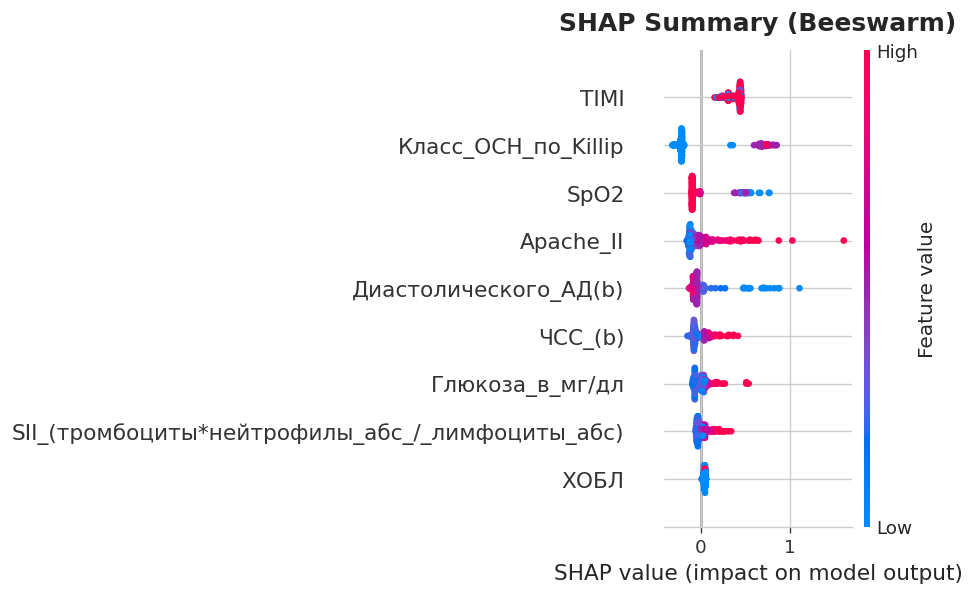

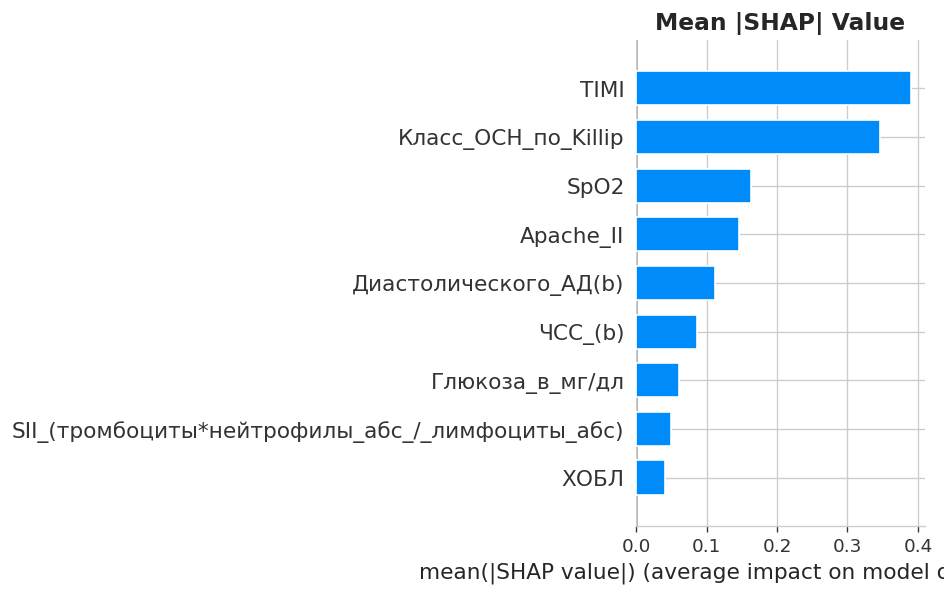

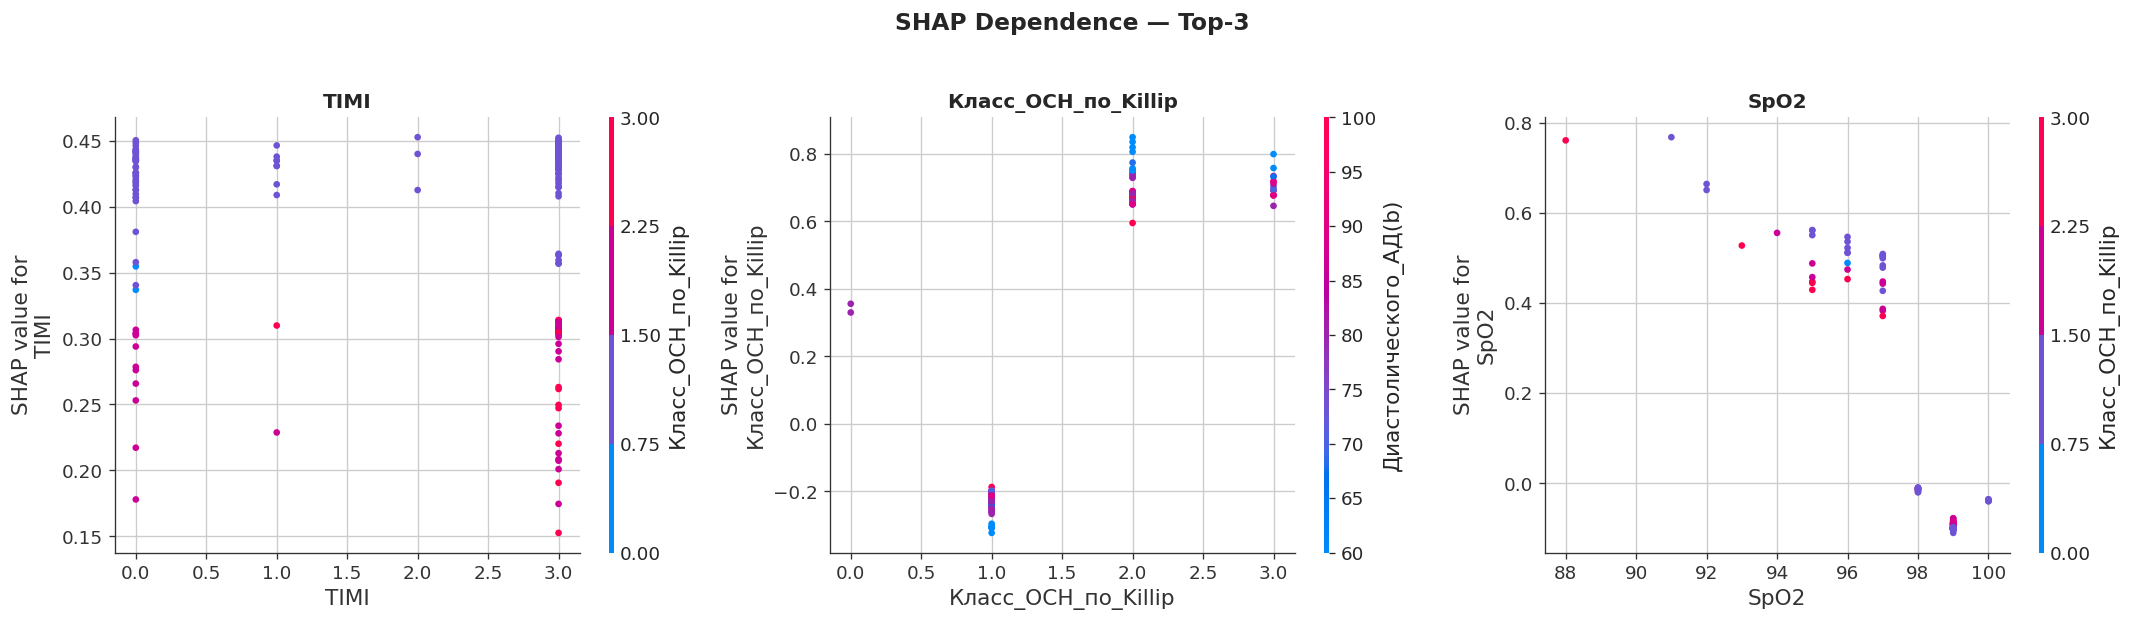

In [355]:
# feature_names_after = xgb_baseline[:-1].get_feature_names_out()
# Ваши категориальные индексы (уже есть в переменной)
CATEGORICAL_INDEXES = X.columns.get_indexer(categorical).tolist()

# Вызов — передаём cat_features явно
shap_cbt = shap_explain(
    model=cbt_baseline,
    X_explain=X_test,
    feature_names=X_test.columns,
    cat_features=CATEGORICAL_INDEXES,    # ← ВОТ ЭТО
    save_dir='.',
)
